<a href="https://colab.research.google.com/github/Adithyasajeev22/EDA/blob/main/ADA_BOOST_%2C_XGBOOST(CLASSIFICATION)_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ADA BOOST , XGBOOST**

# **CLASSIFICATION**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/Gaming and Mental Health.csv')
df.head(5)

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [ ]:
df.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


<Axes: >

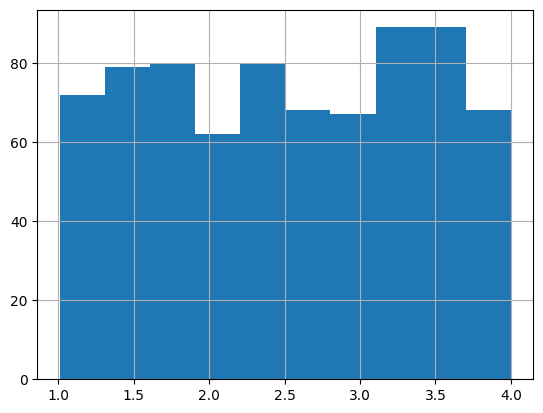

In [ ]:
df['grades_gpa'].hist()

<Axes: >

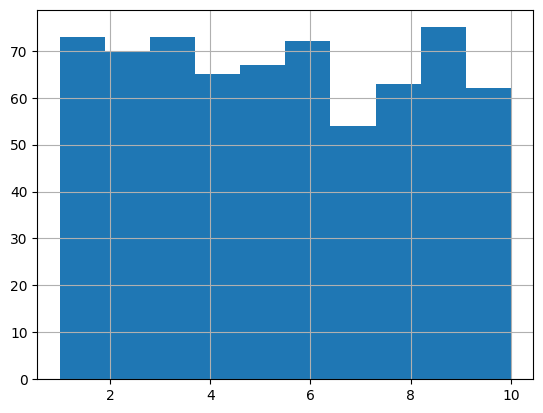

In [ ]:
df['work_productivity_score'].hist()

In [ ]:

df['grades_gpa'] = df['grades_gpa'].fillna(df['grades_gpa'].median())

df['work_productivity_score'] = df['work_productivity_score'].fillna(df['work_productivity_score'].median())

In [ ]:
df.isnull().sum()

,0
record_id,0
age,0
gender,0
daily_gaming_hours,0
game_genre,0
primary_game,0
gaming_platform,0
sleep_hours,0
sleep_quality,0
sleep_disruption_frequency,0


In [ ]:
df.shape

(1000, 27)

In [ ]:
df.duplicated().sum()

np.int64(0)

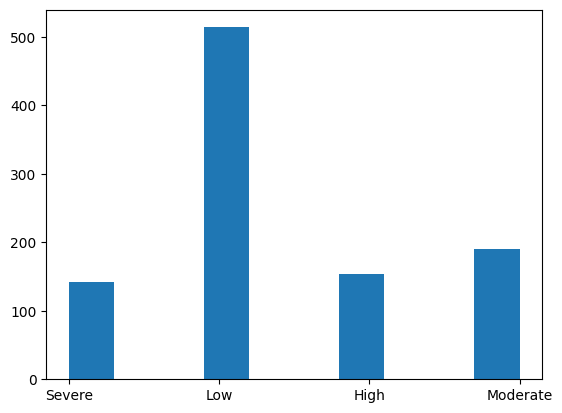

In [ ]:
plt.hist(df['gaming_addiction_risk_level'])
plt.show()

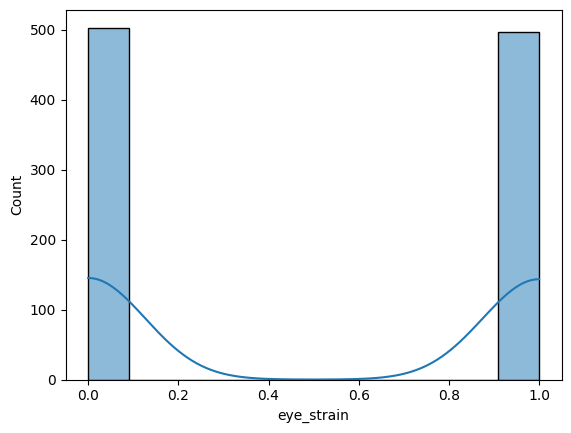

In [ ]:
sns.histplot(df['eye_strain'],kde=True)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        1000 non-null   float64
 12  work_pr

In [ ]:
print(df['record_id'].unique())

['GD0001' 'GD0002' 'GD0003' 'GD0004' 'GD0005' 'GD0006' 'GD0007' 'GD0008'
 'GD0009' 'GD0010' 'GD0011' 'GD0012' 'GD0013' 'GD0014' 'GD0015' 'GD0016'
 'GD0017' 'GD0018' 'GD0019' 'GD0020' 'GD0021' 'GD0022' 'GD0023' 'GD0024'
 'GD0025' 'GD0026' 'GD0027' 'GD0028' 'GD0029' 'GD0030' 'GD0031' 'GD0032'
 'GD0033' 'GD0034' 'GD0035' 'GD0036' 'GD0037' 'GD0038' 'GD0039' 'GD0040'
 'GD0041' 'GD0042' 'GD0043' 'GD0044' 'GD0045' 'GD0046' 'GD0047' 'GD0048'
 'GD0049' 'GD0050' 'GD0051' 'GD0052' 'GD0053' 'GD0054' 'GD0055' 'GD0056'
 'GD0057' 'GD0058' 'GD0059' 'GD0060' 'GD0061' 'GD0062' 'GD0063' 'GD0064'
 'GD0065' 'GD0066' 'GD0067' 'GD0068' 'GD0069' 'GD0070' 'GD0071' 'GD0072'
 'GD0073' 'GD0074' 'GD0075' 'GD0076' 'GD0077' 'GD0078' 'GD0079' 'GD0080'
 'GD0081' 'GD0082' 'GD0083' 'GD0084' 'GD0085' 'GD0086' 'GD0087' 'GD0088'
 'GD0089' 'GD0090' 'GD0091' 'GD0092' 'GD0093' 'GD0094' 'GD0095' 'GD0096'
 'GD0097' 'GD0098' 'GD0099' 'GD0100' 'GD0101' 'GD0102' 'GD0103' 'GD0104'
 'GD0105' 'GD0106' 'GD0107' 'GD0108' 'GD0109' 'GD01

In [ ]:
print(df['gender'].unique())

['Male' 'Female' 'Other']


In [ ]:
print(df['game_genre'].unique())

['Mobile Games' 'MOBA' 'FPS' 'RPG' 'Battle Royale' 'MMO' 'Strategy']


In [ ]:
print(df['primary_game'].unique())

['Clash of Clans' 'Dota 2' 'CS:GO' 'Skyrim' 'Apex Legends' 'Call of Duty'
 'Genshin Impact' 'Final Fantasy XIV' 'StarCraft II' 'Elden Ring'
 'League of Legends' 'Warzone' 'Cyberpunk 2077' 'PUBG' 'Candy Crush'
 'World of Warcraft' 'PUBG Mobile' 'Mobile Legends' 'Elder Scrolls Online'
 'Valorant' 'Age of Empires' 'Civilization VI' 'Fortnite' 'Overwatch']


In [ ]:
print(df['gaming_platform'].unique())

['PC' 'Multi-platform' 'Console' 'Mobile']


In [ ]:
print(df['sleep_quality'].unique())

['Very Poor' 'Fair' 'Poor' 'Insomnia' 'Good']


In [ ]:
print(df['sleep_disruption_frequency'].unique())

['Sometimes' 'Rarely' 'Often' 'Never' 'Always']


In [ ]:
print(df['academic_work_performance'].unique())

['Below Average' 'Good' 'Poor' 'Average' 'Excellent' 'Failing']


In [ ]:
print(df['mood_state'].unique())

['Anxious' 'Irritable' 'Withdrawn' 'Angry' 'Normal' 'Euphoric' 'Restless'
 'Depressed' 'Excited']


In [ ]:
print(df['mood_swing_frequency'].unique())

['Never' 'Often' 'Rarely' 'Daily' 'Sometimes']


In [ ]:
print(df['withdrawal_symptoms'].unique())

[ True False]


In [ ]:
print(df['loss_of_other_interests'].unique())

[False  True]


In [ ]:
print(df['continued_despite_problems'].unique())

[ True False]


In [ ]:
print(df['eye_strain'].unique())

[ True False]


In [ ]:
print(df['back_neck_pain'].unique())

[False  True]


In [ ]:
print(df['gaming_addiction_risk_level'].unique())

['Severe' 'Low' 'High' 'Moderate']


In [ ]:
df['gaming_addiction_risk_level'].replace(['Severe','Low','High','Moderate'],[0,1,2,3],inplace=True)
df['mood_swing_frequency'].replace(['Never','Often','Rarely','Daily','Sometimes'],[0,1,2,3,4],inplace=True)
df['mood_state'].replace(['Anxious','Irritable','Withdrawn','Angry','Normal','Euphoric','Restless','Depressed','Excited'],[0,1,2,3,4,5,6,7,8],inplace=True)
df['academic_work_performance'].replace(['Below Average','Good','Poor','Average','Excellent','Failing'],[0,1,2,3,4,5],inplace=True)
df['sleep_disruption_frequency'].replace(['Sometimes','Rarely','Often','Never','Always'],[0,1,2,3,4],inplace=True)
df['sleep_quality'].replace(['Very Poor','Fair','Poor','Insomnia','Good'],[0,1,2,3,4],inplace=True)
df['gaming_platform'].replace(['PC','Multi-platform','Console','Mobile'],[0,1,2,3],inplace=True)
df['game_genre'].replace(['Mobile Games','MOBA','FPS','RPG','Battle Royale','MMO','Strategy'],[0,1,2,3,4,5,6],inplace=True)
df['gender'].replace(['Male','Female','Other'],[0,1,2],inplace=True)

/tmp/ipykernel_19468/1401034278.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gaming_addiction_risk_level'].replace(['Severe','Low','High','Moderate'],[0,1,2,3],inplace=True)
/tmp/ipykernel_19468/1401034278.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gaming_addiction_risk_level

In [ ]:
df['record_id'] = df['record_id'].str.replace('GD', '', regex=False).astype(int)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['primary_game']=le.fit_transform(df['primary_game'])

In [ ]:
#conver boolean to numeric
df['withdrawal_symptoms'] = df['withdrawal_symptoms'].astype(int)
df['loss_of_other_interests'] = df['loss_of_other_interests'].astype(int)
df['continued_despite_problems'] = df['continued_despite_problems'].astype(int)
df['eye_strain'] = df['eye_strain'].astype(int)
df['back_neck_pain'] = df['back_neck_pain'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   int64  
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   int64  
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   int64  
 5   primary_game                      1000 non-null   int64  
 6   gaming_platform                   1000 non-null   int64  
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   int64  
 9   sleep_disruption_frequency        1000 non-null   int64  
 10  academic_work_performance         1000 non-null   int64  
 11  grades_gpa                        1000 non-null   float64
 12  work_pr

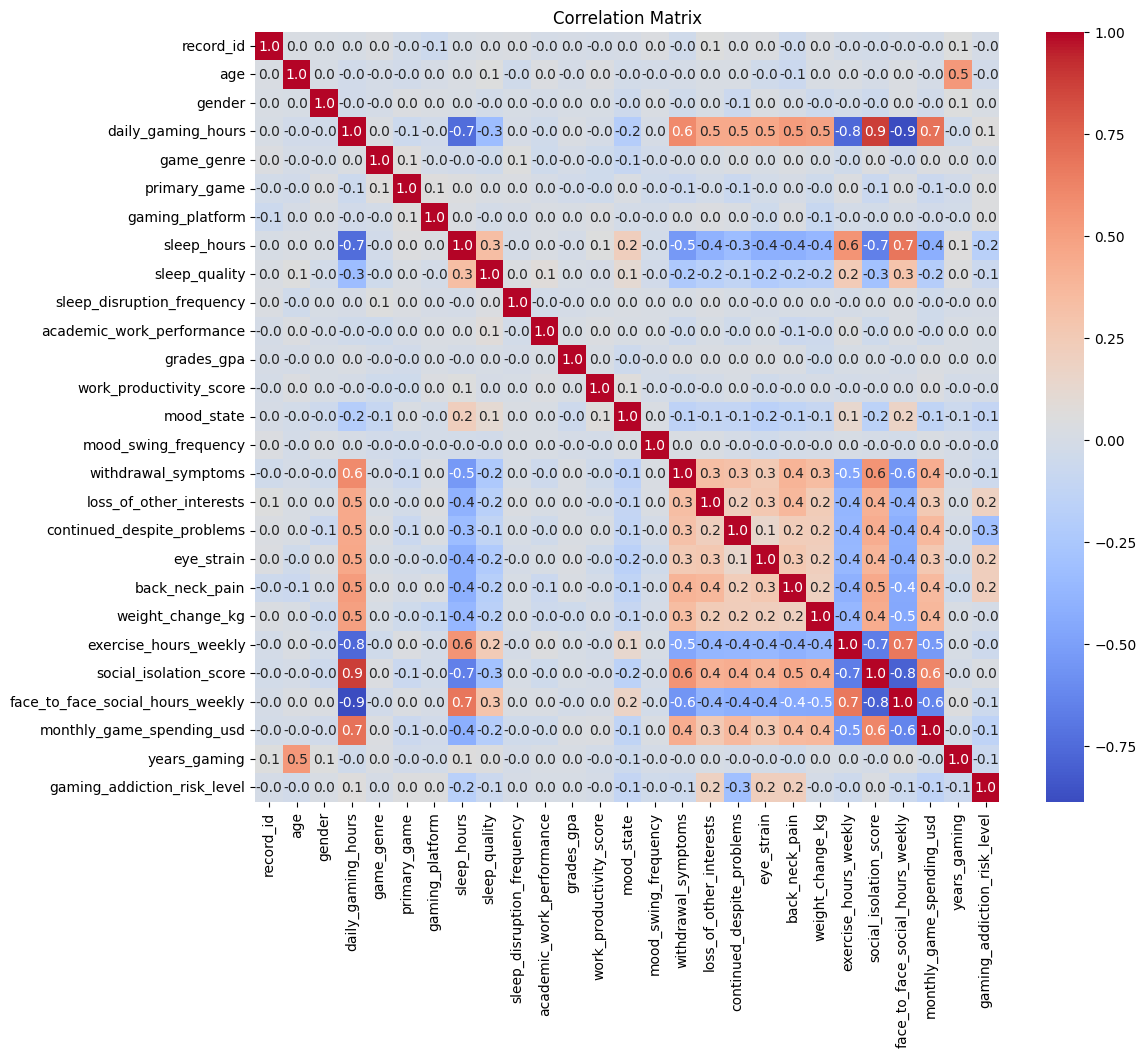

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr()
plt.figure(figsize=(12, 10))  # increase width & height

sns.heatmap(corr_matrix, annot=True, fmt='.01f', cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.drop(["social_isolation_score","monthly_game_spending_usd","daily_gaming_hours","face_to_face_social_hours_weekly","exercise_hours_weekly"],axis=1,inplace=True)

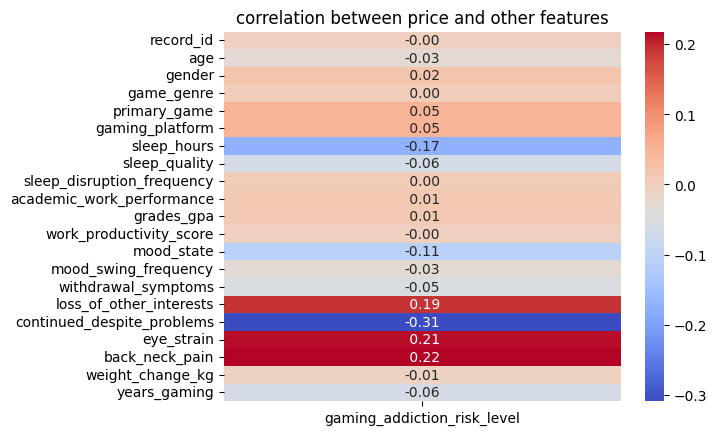

In [ ]:
status_corr=df.corr()["gaming_addiction_risk_level"]
status_corr=status_corr.drop("gaming_addiction_risk_level")
sns.heatmap(status_corr.to_frame(),annot=True,fmt=" .2f",cmap= "coolwarm",cbar=True,annot_kws={'size':10})
plt.title("correlation between price and other features")
plt.show()

In [ ]:
df.drop(['record_id','game_genre','work_productivity_score','sleep_disruption_frequency',],axis=1,inplace=True)

In [ ]:
df.shape

(1000, 18)

<Axes: >

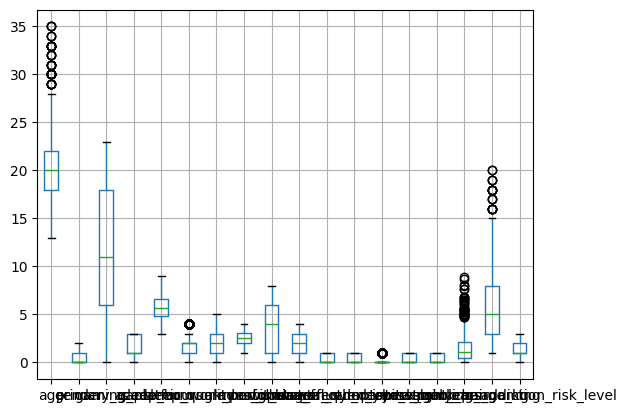

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  df_numeric = df.select_dtypes(include=np.number) # Select only numeric columns
  df_cleaned = df.copy() # Create a copy to modify

  for col in df_numeric.columns:
    if col == exclude_column:
      continue
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
  return df_cleaned

df_cleaned= remove_outliers_iqr(df,exclude_column='gaming_addiction_risk_level')
df=df_cleaned

In [ ]:
df.shape

(589, 18)

In [ ]:
df.columns

Index(['age', 'gender', 'primary_game', 'gaming_platform', 'sleep_hours',
       'sleep_quality', 'academic_work_performance', 'grades_gpa',
       'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'years_gaming',
       'gaming_addiction_risk_level'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
features =['age', 'gender', 'primary_game', 'gaming_platform', 'sleep_hours',
       'sleep_quality', 'academic_work_performance', 'grades_gpa',
       'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'years_gaming']
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['age', 'gender', 'primary_game', 'gaming_platform', 'sleep_hours',
       'sleep_quality', 'academic_work_performance', 'grades_gpa',
       'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'years_gaming']]
y=df["gaming_addiction_risk_level"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.13


In [ ]:

from sklearn.ensemble import AdaBoostClassifier


x=df[['age', 'gender', 'primary_game', 'gaming_platform', 'sleep_hours',
       'sleep_quality', 'academic_work_performance', 'grades_gpa',
       'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'years_gaming']]
y=df["gaming_addiction_risk_level"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.27


In [ ]:

from  xgboost import XGBClassifier


x=df[['age', 'gender', 'primary_game', 'gaming_platform', 'sleep_hours',
       'sleep_quality', 'academic_work_performance', 'grades_gpa',
       'mood_state', 'mood_swing_frequency', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'years_gaming']]
y=df["gaming_addiction_risk_level"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = model.score(x_test,y_test)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.80
